# 📈 Pipeline 2: Comprehensive Visual Analytics & EDA Pipeline
**Project:** Build For Bharat 2.0 — CareerGPS Talent Intelligence  
**Track:** SAS & Data Science Track  

### Overview & Objectives
This notebook provides publication-ready visualizations uncovering structural market patterns, talent skill premiums, geographic hubs, and the predictive traits that drive career advancement.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.size'] = 11
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['figure.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.titleweight'] = 'bold'

cleaned_dir = os.path.abspath(os.path.join("..", "data", "cleaned"))

ds_jobs = pd.read_csv(os.path.join(cleaned_dir, "clean_datascience_jobs.csv"))
an_jobs = pd.read_csv(os.path.join(cleaned_dir, "clean_analytics_jobs.csv"))
jds = pd.read_csv(os.path.join(cleaned_dir, "clean_jds_skill_traits.csv"))
sds = pd.read_csv(os.path.join(cleaned_dir, "clean_sds_personality_traits.csv"))

print(f"Loaded Datasets: DS={ds_jobs.shape}, Analytics={an_jobs.shape}, JDS={jds.shape}, SDS={sds.shape}")


Loaded Datasets: DS=(1602, 14), Analytics=(15841, 35), JDS=(139, 10), SDS=(161, 9)


## 1. Univariate Analysis: Market Distributions
- Offered compensation in Data Science (INR Lakhs per Annum).
- Required experience across Analytics postings (Years).


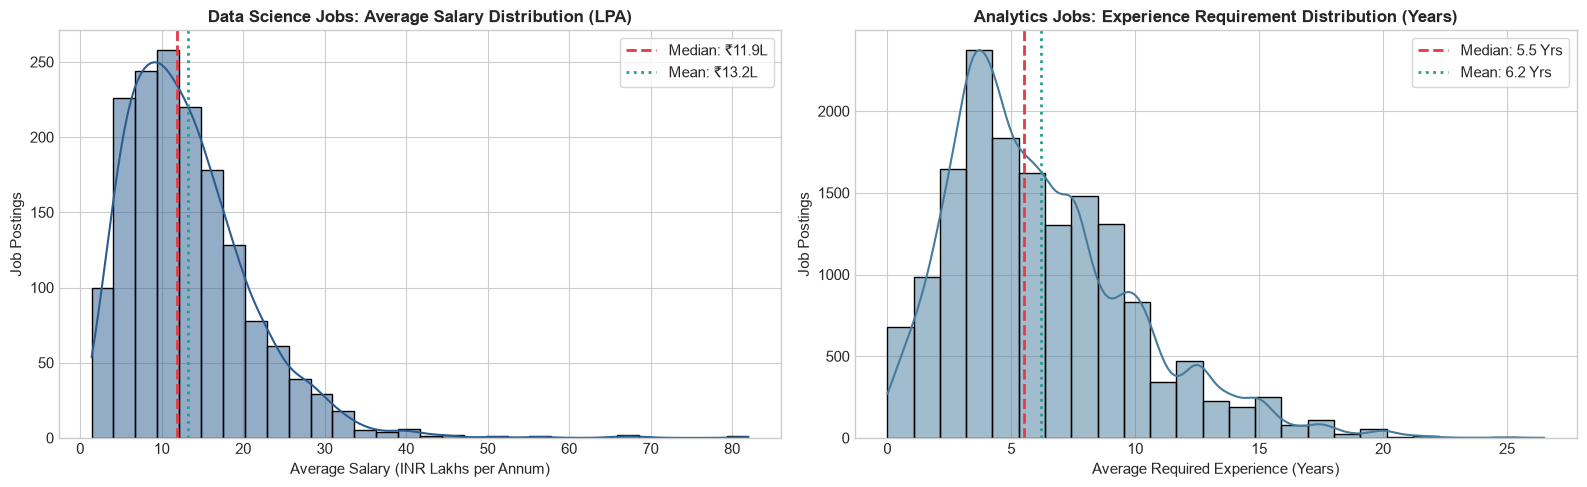

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Salary in Data Science
sns.histplot(ds_jobs['avg_salary_lakhs'], kde=True, color='#2b5c8f', bins=30, ax=axes[0])
axes[0].axvline(ds_jobs['avg_salary_lakhs'].median(), color='#e63946', linestyle='--', linewidth=2, label=f"Median: ₹{ds_jobs['avg_salary_lakhs'].median():.1f}L")
axes[0].axvline(ds_jobs['avg_salary_lakhs'].mean(), color='#2a9d8f', linestyle=':', linewidth=2, label=f"Mean: ₹{ds_jobs['avg_salary_lakhs'].mean():.1f}L")
axes[0].set_title("Data Science Jobs: Average Salary Distribution (LPA)")
axes[0].set_xlabel("Average Salary (INR Lakhs per Annum)")
axes[0].set_ylabel("Job Postings")
axes[0].legend(frameon=True)

# 2. Experience in Analytics
sns.histplot(an_jobs['avg_experience_years'], kde=True, color='#457b9d', bins=25, ax=axes[1])
axes[1].axvline(an_jobs['avg_experience_years'].median(), color='#e63946', linestyle='--', linewidth=2, label=f"Median: {an_jobs['avg_experience_years'].median():.1f} Yrs")
axes[1].axvline(an_jobs['avg_experience_years'].mean(), color='#2a9d8f', linestyle=':', linewidth=2, label=f"Mean: {an_jobs['avg_experience_years'].mean():.1f} Yrs")
axes[1].set_title("Analytics Jobs: Experience Requirement Distribution (Years)")
axes[1].set_xlabel("Average Required Experience (Years)")
axes[1].set_ylabel("Job Postings")
axes[1].legend(frameon=True)

plt.tight_layout()
plt.show()


## 2. In-Demand Skills & Geographic Clusters
Examining the top technical competencies across 15,841 job postings and the distribution across major tech hubs.


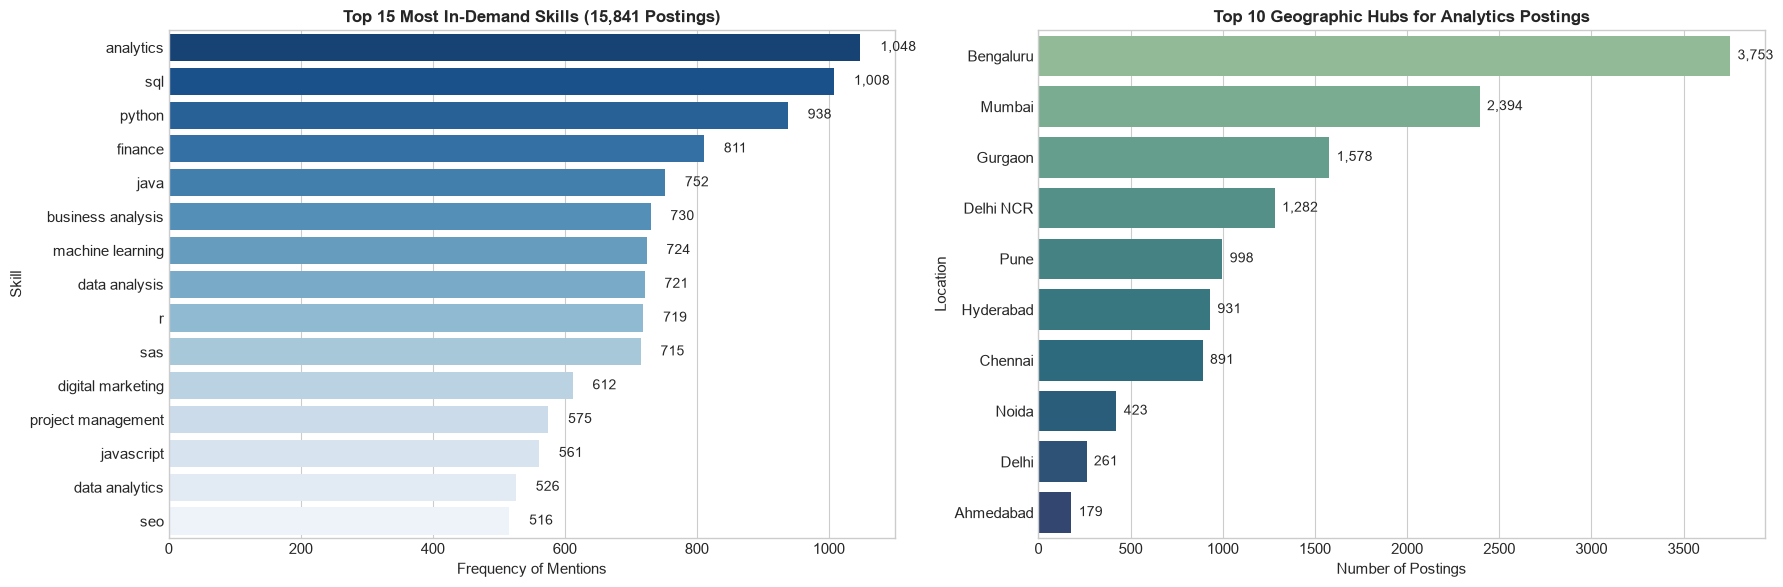

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Top 15 Skills
all_skills = an_jobs['key_skills_clean'].str.split(',').explode().str.strip()
all_skills = all_skills[all_skills != '']
top_skills = all_skills.value_counts().head(15)

sns.barplot(x=top_skills.values, y=top_skills.index, palette='Blues_r', hue=top_skills.index, legend=False, ax=axes[0])
axes[0].set_title("Top 15 Most In-Demand Skills (15,841 Postings)")
axes[0].set_xlabel("Frequency of Mentions")
axes[0].set_ylabel("Skill")
for i, v in enumerate(top_skills.values):
    axes[0].text(v + 30, i, f"{v:,}", va='center', fontsize=10)

# Top 10 Locations
top_locs = an_jobs['primary_location'].value_counts().head(10)
sns.barplot(x=top_locs.values, y=top_locs.index, palette='crest', hue=top_locs.index, legend=False, ax=axes[1])
axes[1].set_title("Top 10 Geographic Hubs for Analytics Postings")
axes[1].set_xlabel("Number of Postings")
axes[1].set_ylabel("Location")
for i, v in enumerate(top_locs.values):
    axes[1].text(v + 40, i, f"{v:,}", va='center', fontsize=10)

plt.tight_layout()
plt.show()


## 3. Compensation Bands by Role & Seniority
Analyzing median, interquartile ranges, and salary tiers across standardized Data Science roles.


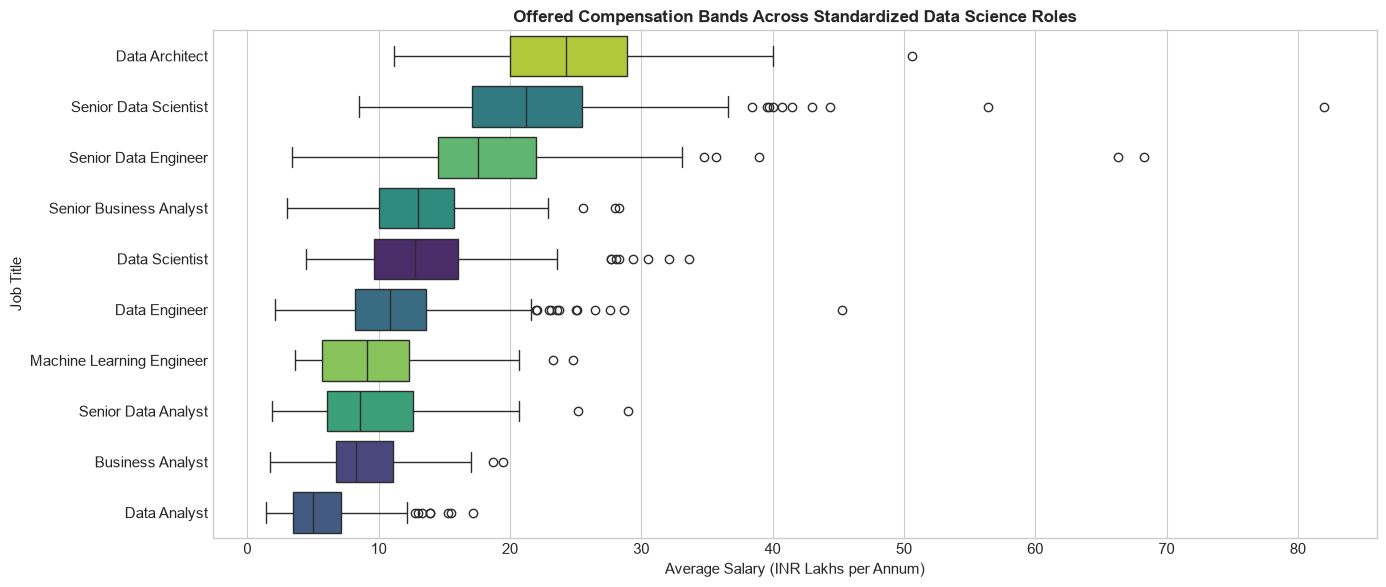

In [4]:
plt.figure(figsize=(14, 6))
order = ds_jobs.groupby('job_title')['avg_salary_lakhs'].median().sort_values(ascending=False).index
sns.boxplot(data=ds_jobs, y='job_title', x='avg_salary_lakhs', order=order, palette='viridis', hue='job_title', legend=False)
plt.title("Offered Compensation Bands Across Standardized Data Science Roles")
plt.xlabel("Average Salary (INR Lakhs per Annum)")
plt.ylabel("Job Title")
plt.tight_layout()
plt.show()


## 4. JDS & SDS Trait Comparisons vs Career Outcomes
- **JDS**: How individual technical competencies differentiate Junior Data Scientists who receive High vs Low salary hikes.
- **SDS**: How Big Five (OCEAN) traits differentiate Senior Data Scientists with High vs Low customer-facing success.


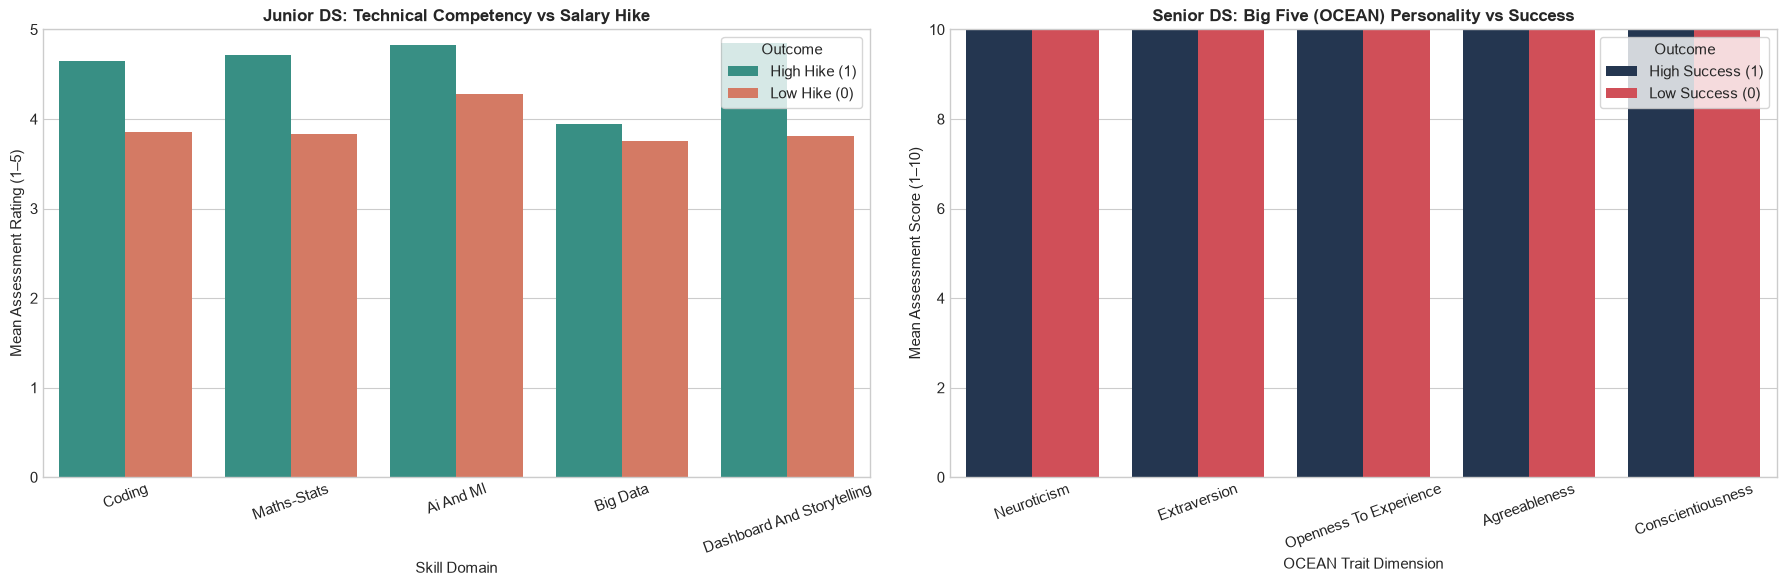

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# JDS Skills vs Hike
skill_cols = ['coding_skills', 'maths-stats_skills', 'ai_and_ml_skills', 'big_data_skills', 'dashboard_and_storytelling_skills']
jds_melted = jds.melt(id_vars=['salary_hike_high_or_low'], value_vars=skill_cols, var_name='Skill', value_name='Rating')
jds_melted['Skill'] = jds_melted['Skill'].str.replace('_skills', '').str.replace('_', ' ').str.title()
jds_melted['Hike_Label'] = jds_melted['salary_hike_high_or_low'].map({1: 'High Hike (1)', 0: 'Low Hike (0)'})

sns.barplot(data=jds_melted, x='Skill', y='Rating', hue='Hike_Label', palette={'High Hike (1)': '#2a9d8f', 'Low Hike (0)': '#e76f51'}, ax=axes[0], errorbar=None)
axes[0].set_title("Junior DS: Technical Competency vs Salary Hike")
axes[0].set_xlabel("Skill Domain")
axes[0].set_ylabel("Mean Assessment Rating (1–5)")
axes[0].set_ylim(0, 5)
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(title="Outcome", frameon=True)

# SDS OCEAN vs Success
ocean_cols = ['neuroticism', 'extraversion', 'openness_to_experience', 'agreeableness', 'conscientiousness']
sds_melted = sds.melt(id_vars=['success_classification_high_low'], value_vars=ocean_cols, var_name='Trait', value_name='Score')
sds_melted['Trait'] = sds_melted['Trait'].str.replace('_', ' ').str.title()
sds_melted['Success_Label'] = sds_melted['success_classification_high_low'].map({1: 'High Success (1)', 0: 'Low Success (0)'})

sns.barplot(data=sds_melted, x='Trait', y='Score', hue='Success_Label', palette={'High Success (1)': '#1d3557', 'Low Success (0)': '#e63946'}, ax=axes[1], errorbar=None)
axes[1].set_title("Senior DS: Big Five (OCEAN) Personality vs Success")
axes[1].set_xlabel("OCEAN Trait Dimension")
axes[1].set_ylabel("Mean Assessment Score (1–10)")
axes[1].set_ylim(0, 10)
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(title="Outcome", frameon=True)

plt.tight_layout()
plt.show()


## 5. Correlation Heatmaps: Technical Skills & Psychometric Drivers
Visualizing linear correlations among technical competencies (JDS) and OCEAN traits (SDS).


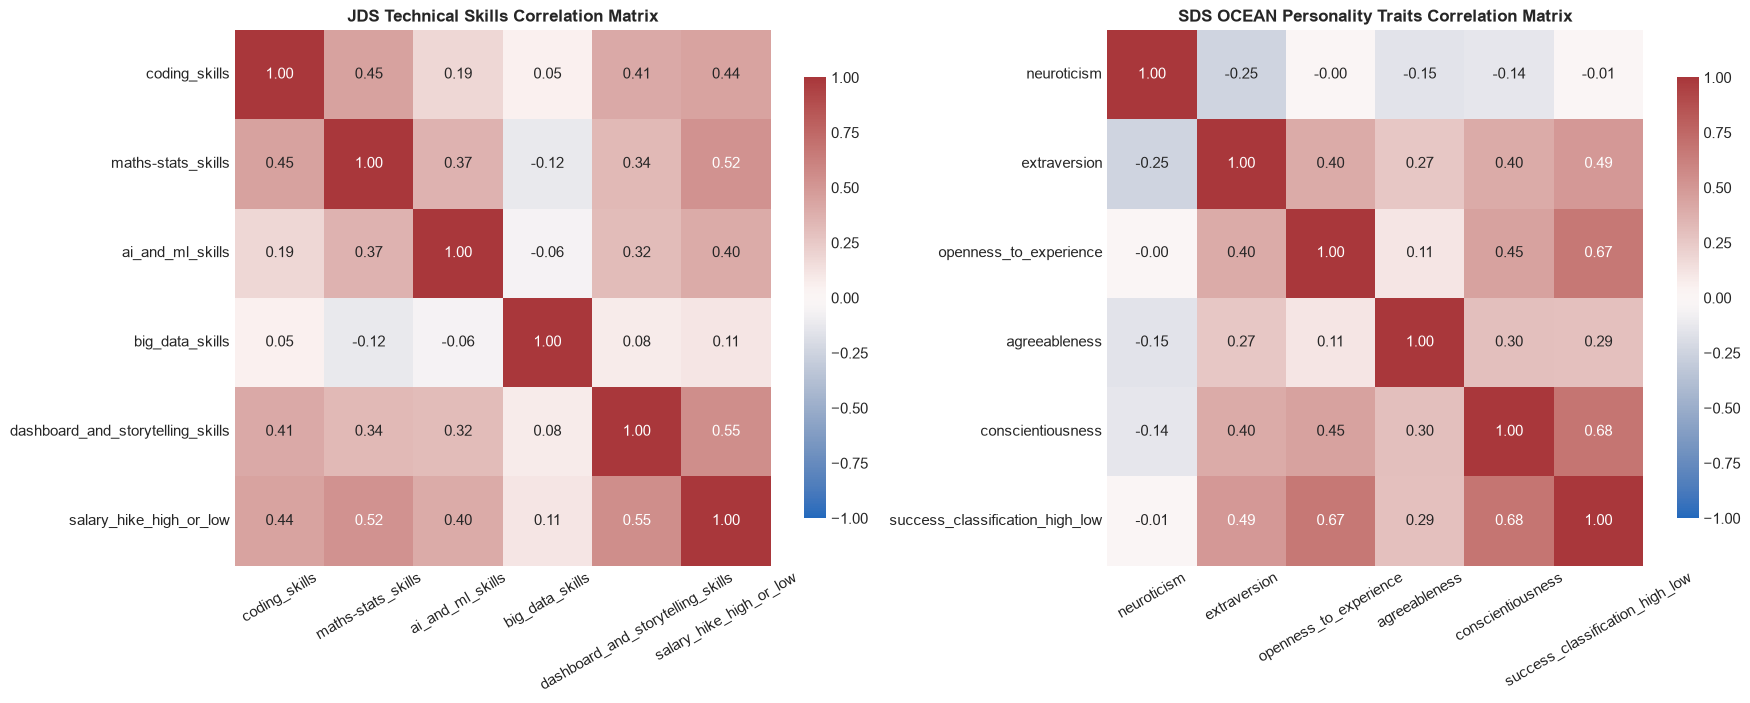

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# JDS Correlation Heatmap
jds_corr = jds[skill_cols + ['salary_hike_high_or_low']].corr()
sns.heatmap(jds_corr, annot=True, fmt='.2f', cmap='vlag', vmin=-1, vmax=1, square=True, ax=axes[0], cbar_kws={'shrink': 0.8})
axes[0].set_title("JDS Technical Skills Correlation Matrix")
axes[0].tick_params(axis='x', rotation=30)

# SDS Correlation Heatmap
sds_corr = sds[ocean_cols + ['success_classification_high_low']].corr()
sns.heatmap(sds_corr, annot=True, fmt='.2f', cmap='vlag', vmin=-1, vmax=1, square=True, ax=axes[1], cbar_kws={'shrink': 0.8})
axes[1].set_title("SDS OCEAN Personality Traits Correlation Matrix")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


## 6. Statistical Hypothesis Testing
Rigorous parametric (Student's t-test) and non-parametric (Mann-Whitney U) tests quantifying the statistical significance of trait differentials between high and low performance groups.


In [7]:
stats_records = []

# JDS tests
for col in skill_cols:
    g_high = jds[jds['salary_hike_high_or_low'] == 1][col]
    g_low = jds[jds['salary_hike_high_or_low'] == 0][col]
    t_stat, p_val = stats.ttest_ind(g_high, g_low)
    u_stat, u_pval = stats.mannwhitneyu(g_high, g_low)
    stats_records.append({
        "Dataset": "JDS (Technical)",
        "Feature": col,
        "Mean (High)": round(g_high.mean(), 2),
        "Mean (Low)": round(g_low.mean(), 2),
        "Diff": round(g_high.mean() - g_low.mean(), 2),
        "t-statistic": round(t_stat, 3),
        "p-value": f"{p_val:.4e}",
        "Significant (α=0.05)": "Yes" if p_val < 0.05 else "No"
    })

# SDS tests
for col in ocean_cols:
    g_high = sds[sds['success_classification_high_low'] == 1][col]
    g_low = sds[sds['success_classification_high_low'] == 0][col]
    t_stat, p_val = stats.ttest_ind(g_high, g_low)
    u_stat, u_pval = stats.mannwhitneyu(g_high, g_low)
    stats_records.append({
        "Dataset": "SDS (OCEAN)",
        "Feature": col,
        "Mean (High)": round(g_high.mean(), 2),
        "Mean (Low)": round(g_low.mean(), 2),
        "Diff": round(g_high.mean() - g_low.mean(), 2),
        "t-statistic": round(t_stat, 3),
        "p-value": f"{p_val:.4e}",
        "Significant (α=0.05)": "Yes" if p_val < 0.05 else "No"
    })

df_hypothesis = pd.DataFrame(stats_records)
print("=== STATISTICAL HYPOTHESIS TESTING SUMMARY ===")
display(df_hypothesis)


=== STATISTICAL HYPOTHESIS TESTING SUMMARY ===


,Dataset,Feature,Mean (High),Mean (Low),Diff,t-statistic,p-value,Significant (α=0.05)
0,JDS (Technical),coding_skills,4.64,3.85,0.79,5.797,4.4375e-08,Yes
1,JDS (Technical),maths-stats_skills,4.71,3.83,0.88,7.197,3.6716e-11,Yes
2,JDS (Technical),ai_and_ml_skills,4.82,4.28,0.54,5.179,7.7974e-07,Yes
3,JDS (Technical),big_data_skills,3.94,3.75,0.19,1.323,1.8804e-01,No
4,JDS (Technical),dashboard_and_storytelling_skills,4.85,3.81,1.03,7.791,1.4871e-12,Yes
5,SDS (OCEAN),neuroticism,36.13,36.26,-0.13,-0.075,9.4035e-01,No
6,SDS (OCEAN),extraversion,48.86,36.88,11.98,7.170,2.6726e-11,Yes
7,SDS (OCEAN),openness_to_experience,48.49,33.32,15.18,11.421,1.9379e-22,Yes
8,SDS (OCEAN),agreeableness,47.72,41.12,6.60,3.859,1.6532e-04,Yes
9,SDS (OCEAN),conscientiousness,53.68,35.74,17.95,11.701,3.3067e-23,Yes
